# Spam Message Detection Using NLP and Machine Learning

### Mini NLP Project

This project uses Natural Language Processing (NLP) and Machine Learning to classify SMS messages as Spam or Ham.

## 1. Introduction

Spam messages are unwanted messages that may contain advertisements, fraudulent offers, scams, or irrelevant information.

The aim of this project is to develop an NLP-based system that can automatically classify SMS messages into Spam and Ham (Not Spam).

The project uses text preprocessing, TF-IDF feature extraction, and the Multinomial Naive Bayes machine learning algorithm.

## 2. Problem Statement

The increasing number of unwanted and spam messages makes it difficult for users to manually identify potentially harmful or irrelevant messages.

The objective is to develop an NLP-based classification system that automatically identifies whether an SMS message is Spam or Ham.

## 3. Objectives

- To understand the application of NLP in text classification.
- To preprocess SMS text data.
- To convert text into numerical features using TF-IDF.
- To train a machine learning classification model.
- To classify messages as Spam or Ham.
- To evaluate the model using suitable performance metrics.
- To test the model using new user-entered messages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 4. Dataset

The SMS Spam Collection dataset is used for this project.

**Attributes:**
- Label – Spam or Ham
- Message – Actual SMS text

**Target Variable:** Spam or Ham

In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
urllib.request.urlretrieve(url, "spam.tsv")

df = pd.read_csv("spam.tsv", sep="\t", header=None, names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["label"].value_counts())

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label      0
message    0
dtype: int64


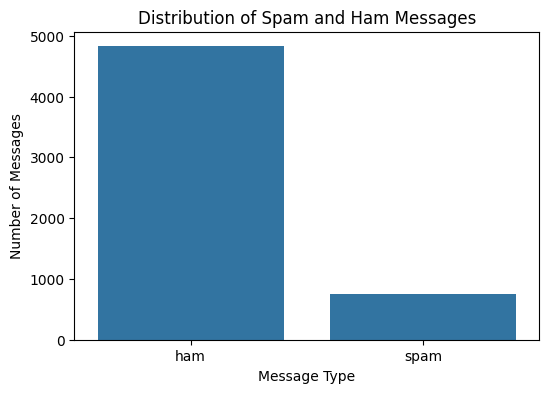

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

## 5. Methodology

SMS Dataset → Text Preprocessing → TF-IDF Feature Extraction → Train-Test Split → Naive Bayes Classification → Prediction → Evaluation

In [6]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Text Preprocessing

The messages are converted to lowercase, unnecessary characters are removed, and extra spaces are cleaned.

In [7]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_message"] = df["message"].apply(preprocess_text)
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


### Train-Test Split

80% of the data is used for training and 20% is used for testing.

In [8]:
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


### TF-IDF Feature Extraction

TF-IDF converts text messages into numerical feature vectors that can be used by the machine learning model.

In [9]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4457, 5000)
Testing TF-IDF Shape: (1115, 5000)


## 6. Model Selection

The Multinomial Naive Bayes algorithm is selected because it is simple, fast, and suitable for text classification with TF-IDF features.

In [10]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
print("Model training completed successfully!")

Model training completed successfully!


## 7. Prediction

The trained model is used to predict the labels of unseen test messages.

In [11]:
y_pred = model.predict(X_test_tfidf)
print("Prediction completed successfully!")

Prediction completed successfully!


## 8. Model Evaluation

The model is evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Performance
-------------------------
Accuracy  : 0.9659
Precision : 1.0000
Recall    : 0.7450
F1-Score  : 0.8538


In [13]:
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



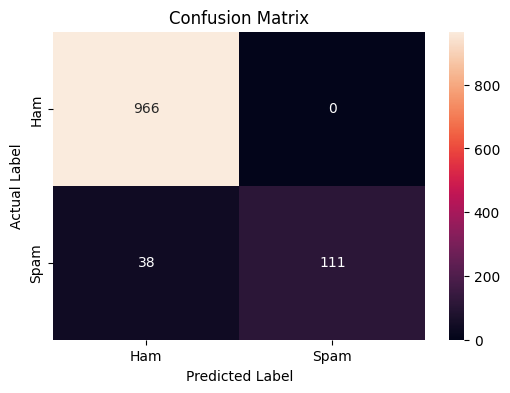

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

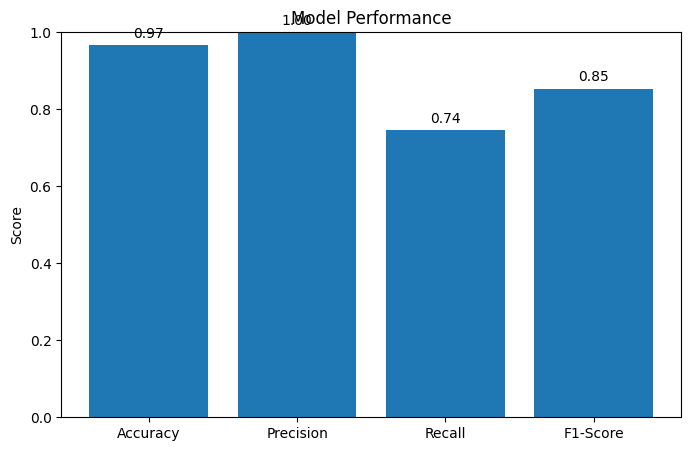

In [15]:
metrics = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}
plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance")
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")
plt.show()

## 9. Testing New Messages

The trained model can classify a new SMS message entered by the user.

In [16]:
def predict_message(message):
    cleaned_message = preprocess_text(message)
    message_tfidf = tfidf.transform([cleaned_message])
    prediction = model.predict(message_tfidf)[0]
    return "SPAM" if prediction == 1 else "HAM"

In [17]:
message = input("Enter a message: ")
result = predict_message(message)
print("\nPrediction:", result)

Enter a message: Congratulations! You have won a free prize!

Prediction: SPAM


## 10. Results

The model performance is measured using accuracy, precision, recall, F1-score, and the confusion matrix. The actual values generated above should be included in the final report.

## 11. Limitations

- The performance depends on the quality of the dataset.
- The model may incorrectly classify unseen messages.
- Sarcasm and unusual language may be difficult to detect.
- New types of spam messages may not always be identified correctly.
- The model is primarily designed for SMS text classification.

## 12. Future Scope

- Use a larger and more diverse dataset.
- Compare different machine learning algorithms.
- Use advanced NLP models such as BERT.
- Add multilingual support.
- Develop a real-time spam detection system.
- Deploy the model as a web or mobile application.

## 13. Conclusion

This project developed an NLP-based SMS spam detection system using text preprocessing, TF-IDF feature extraction, and the Multinomial Naive Bayes algorithm. The system classifies SMS messages as Spam or Ham and evaluates its performance using standard classification metrics.